# Lab 1

**Name:** K Hiroshini  
**Roll No:** CH.SC.U4AIE24026

## Step-by-Step Code Logic

| Component | Implementation Logic / Formula |
|-----------|-------------------------------|
| Activation Function (Heaviside Step) | $f(x) = \begin{cases} 1 & \text{if } x \geq 0 \\ 0 & \text{if } x < 0 \end{cases}$ |
| Weight Update Rule ($\Delta w$) | $\Delta w = \eta \cdot (y - \hat{y}) \cdot x$ |
| Prediction Logic ($\hat{y}$) | $\hat{y} = f(w \cdot x + b)$ |

## Training Loop Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return 1 if x >= 0 else 0

def train_perceptron(X, y, lr=0.1, epochs=10):
    weights = np.zeros(X.shape[1])
    bias = 0
    for _ in range(epochs):
        for i in range(len(X)):
            linear_output = np.dot(X[i], weights) + bias
            y_pred = 1 if linear_output >= 0 else 0
            update = lr * (y[i] - y_pred)
            weights += update * X[i]
            bias += update
    return weights, bias

print("Done")

Done


## Output Analysis

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

weights, bias = train_perceptron(X, y, lr=0.1, epochs=10)

print("Dataset Used: AND Gate")
print("Final Weights:", weights)
print("Final Bias:", bias)
print("Decision Boundary: %.4f*x1 + %.4f*x2 + %.4f = 0" % (weights[0], weights[1], bias))

for i in range(len(X)):
    linear = np.dot(X[i], weights) + bias
    pred = 1 if linear >= 0 else 0
    print(f"Input: {X[i]} -> Predicted: {pred}, Actual: {y[i]}")

correct = sum(1 for i in range(len(X)) if (1 if np.dot(X[i], weights) + bias >= 0 else 0) == y[i])
print(f"Accuracy: {correct / len(X) * 100}%")

Dataset Used: AND Gate
Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004
Decision Boundary: 0.2000*x1 + 0.1000*x2 + -0.2000 = 0
Input: [0 0] -> Predicted: 0, Actual: 0
Input: [0 1] -> Predicted: 0, Actual: 0
Input: [1 0] -> Predicted: 0, Actual: 0
Input: [1 1] -> Predicted: 1, Actual: 1
Accuracy: 100.0%


## Decision Boundary Visualization

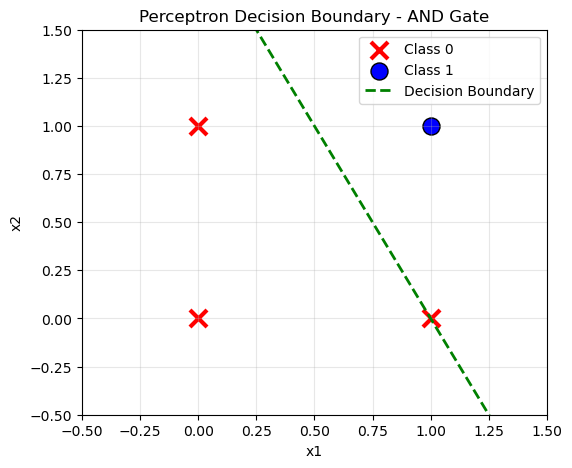

In [3]:
plt.figure(figsize=(6, 5))

for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i][0], X[i][1], color='blue', s=150, marker='o', edgecolors='k', label='Class 1' if i == 3 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color='red', s=150, marker='x', linewidths=3, label='Class 0' if i == 0 else "")

x1_vals = np.linspace(-0.5, 1.5, 100)
if abs(weights[1]) > 1e-5:
    x2_vals = -(weights[0] * x1_vals + bias) / weights[1]
    plt.plot(x1_vals, x2_vals, 'g--', linewidth=2, label='Decision Boundary')
else:
    plt.axvline(x=-bias/weights[0], color='g', linestyle='--', linewidth=2, label='Decision Boundary')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Perceptron Decision Boundary - AND Gate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()